<a href="https://colab.research.google.com/github/rohitblpprajapat/100-days-of-code/blob/master/vision_dsai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install ultralytics transformers torch torchvision opencv-python matplotlib

Loading models...


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Models loaded successfully.
Processing Frame...


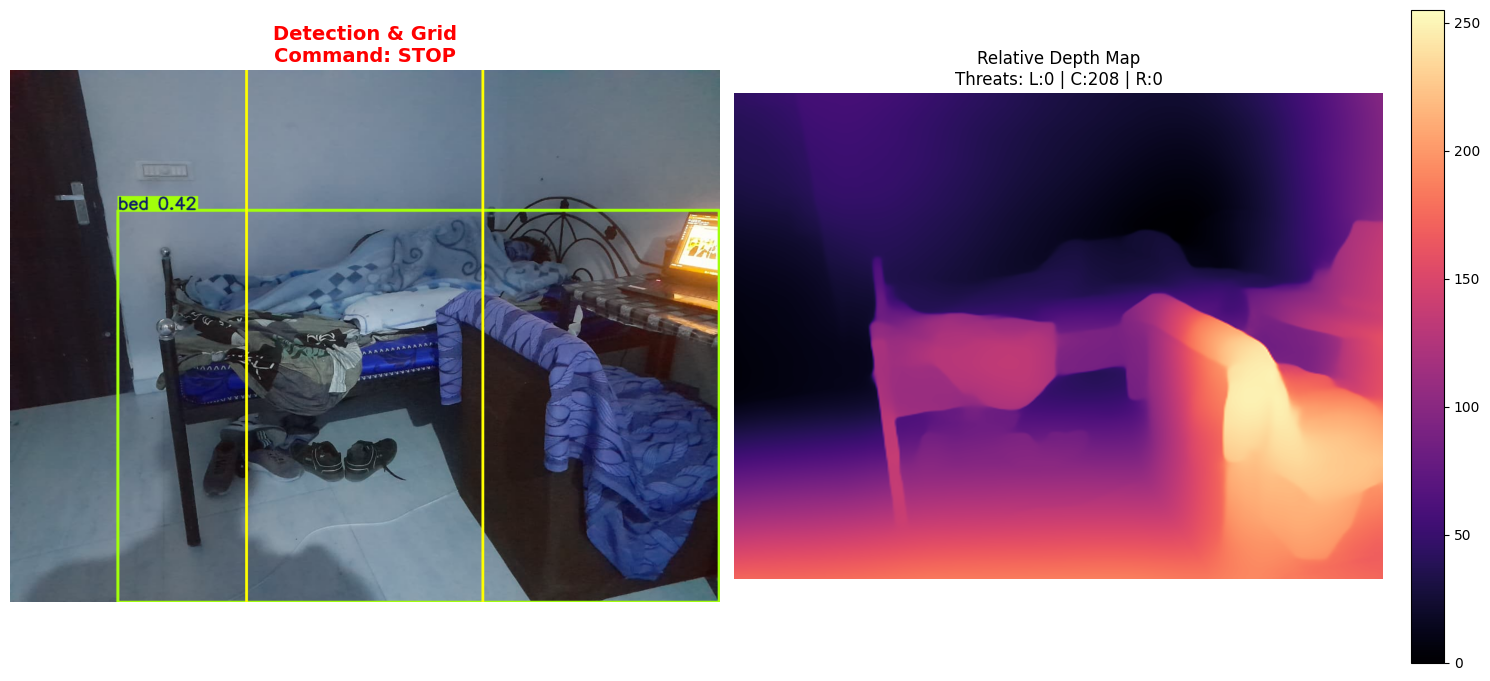

In [11]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from transformers import pipeline
from PIL import Image
import urllib.request

# ==========================================
# 1. Model Initialization
# ==========================================
print("Loading models...")
# Using YOLOv8 Nano for maximum speed (ideal for eventual edge deployment)
yolo_model = YOLO("yolov8n.pt")

# Using a lightweight depth estimation model
# Note: This outputs *relative* depth. For true metric depth, models like ZoeDepth or Google DMD are used,
# but they are heavier. We will use a thresholding heuristic for this POC.
depth_estimator = pipeline(task="depth-estimation", model="Intel/dpt-large")
print("Models loaded successfully.")

# ==========================================
# 2. Rule-Based Navigation Logic
# ==========================================
def get_directional_command(boxes, depth_map, img_width):
    """
    Evaluates obstacles based on an interpretable Left/Center/Right grid.
    """
    # Grid boundaries
    left_boundary = img_width // 3
    right_boundary = 2 * (img_width // 3)

    # We will track the most severe threat in each zone
    # Higher depth map value = closer to camera
    zone_threats = {"Left": 0, "Center": 0, "Right": 0}

    # DANGER_THRESHOLD represents our 0-3 meter cutoff.
    # (In a real deployment, you would calibrate this relative value to actual metric distance)
    DANGER_THRESHOLD = 150

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Calculate the center X of the bounding box to determine its zone
        center_x = (x1 + x2) // 2

        if center_x < left_boundary:
            zone = "Left"
        elif center_x > right_boundary:
            zone = "Right"
        else:
            zone = "Center"

        # Extract the depth region for this specific bounding box
        # We use the 90th percentile to ignore background noise within the box
        box_depth_region = depth_map[y1:y2, x1:x2]
        if box_depth_region.size > 0:
            obstacle_proximity = np.percentile(box_depth_region, 90)

            # Update the threat level for the zone if this object is closer
            if obstacle_proximity > zone_threats[zone]:
                zone_threats[zone] = obstacle_proximity

    # --- Rule-Based Decision Tree ---
    command = "Path Clear - Move Forward"

    # Priority 1: Immediate Frontal Collision (Safety Critical)
    if zone_threats["Center"] > DANGER_THRESHOLD:
        command = "STOP"
        # Secondary logic: Find an escape route
        if zone_threats["Left"] < DANGER_THRESHOLD and zone_threats["Right"] >= DANGER_THRESHOLD:
            command = "STOP - Turn Left"
        elif zone_threats["Right"] < DANGER_THRESHOLD and zone_threats["Left"] >= DANGER_THRESHOLD:
            command = "STOP - Turn Right"

    # Priority 2: Side obstacle avoidance (Drift correction)
    elif zone_threats["Left"] > DANGER_THRESHOLD:
        command = "Drift Right"
    elif zone_threats["Right"] > DANGER_THRESHOLD:
        command = "Drift Left"

    return command, zone_threats

# ==========================================
# 3. Main Processing Function
# ==========================================
def process_frame(image_path):
    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Run YOLO Object Detection
    results = yolo_model(img_rgb, verbose=False)
    boxes = results[0].boxes

    # Run Depth Estimation
    pil_img = Image.fromarray(img_rgb)
    depth_output = depth_estimator(pil_img)

    # The depth model outputs a PIL Image, convert to numpy array and resize to match original image
    depth_map = np.array(depth_output["depth"])
    depth_map = cv2.resize(depth_map, (w, h))

    # Execute Rule-Based Logic
    command, threats = get_directional_command(boxes, depth_map, w)

    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    # Plot original image with bounding boxes and grid lines
    img_annotated = results[0].plot()
    cv2.line(img_annotated, (w//3, 0), (w//3, h), (0, 255, 255), 3) # Left grid line
    cv2.line(img_annotated, (2*(w//3), 0), (2*(w//3), h), (0, 255, 255), 3) # Right grid line

    ax1.imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Detection & Grid\nCommand: {command}", fontsize=14, fontweight='bold', color='red')
    ax1.axis('off')

    # Plot depth map
    im2 = ax2.imshow(depth_map, cmap='magma')
    ax2.set_title(f"Relative Depth Map\nThreats: L:{threats['Left']:.0f} | C:{threats['Center']:.0f} | R:{threats['Right']:.0f}")
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()



print("Processing Frame...")
process_frame("/content/WhatsApp Image 2026-02-27 at 9.25.31 AM.jpeg")

In [12]:
from tqdm import tqdm

In [14]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from transformers import pipeline
from PIL import Image
from tqdm import tqdm # For a progress bar in Colab

# ==========================================
# 1. Model Initialization (Run once)
# ==========================================
print("Loading models...")
yolo_model = YOLO("yolov8n.pt")
depth_estimator = pipeline(task="depth-estimation", model="Intel/dpt-large")
print("Models loaded successfully.")

# ==========================================
# 2. Rule-Based Navigation Logic
# ==========================================
def get_directional_command(boxes, depth_map, img_width):
    # Grid boundaries
    left_boundary = img_width // 3
    right_boundary = 2 * (img_width // 3)

    zone_threats = {"Left": 0, "Center": 0, "Right": 0}
    DANGER_THRESHOLD = 150 # Adjust this based on your depth model's output range

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        center_x = (x1 + x2) // 2

        if center_x < left_boundary:
            zone = "Left"
        elif center_x > right_boundary:
            zone = "Right"
        else:
            zone = "Center"

        box_depth_region = depth_map[y1:y2, x1:x2]
        if box_depth_region.size > 0:
            obstacle_proximity = np.percentile(box_depth_region, 90)
            if obstacle_proximity > zone_threats[zone]:
                zone_threats[zone] = obstacle_proximity

    # --- Rule-Based Decision Tree ---
    command = "Path Clear - Move Forward"
    command_color = (0, 255, 0) # Green

    if zone_threats["Center"] > DANGER_THRESHOLD:
        command = "STOP"
        command_color = (0, 0, 255) # Red
        if zone_threats["Left"] < DANGER_THRESHOLD and zone_threats["Right"] >= DANGER_THRESHOLD:
            command = "STOP - Turn Left"
        elif zone_threats["Right"] < DANGER_THRESHOLD and zone_threats["Left"] >= DANGER_THRESHOLD:
            command = "STOP - Turn Right"

    elif zone_threats["Left"] > DANGER_THRESHOLD:
        command = "Drift Right"
        command_color = (0, 165, 255) # Orange
    elif zone_threats["Right"] > DANGER_THRESHOLD:
        command = "Drift Left"
        command_color = (0, 165, 255) # Orange

    return command, command_color, zone_threats

# ==========================================
# 3. Video Processing Function
# ==========================================
def process_video(input_video_path, output_video_path):
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {input_video_path}")
        return

    # Get video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # We are putting the RGB and Depth frames side-by-side, so the output width is doubled
    out_width = width * 2

    # Initialize VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (out_width, height))

    print(f"Processing Video: {total_frames} frames at {fps} FPS...")

    for _ in tqdm(range(total_frames)):
        ret, frame = cap.read()
        if not ret:
            break

        # 1. Object Detection
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = yolo_model(img_rgb, verbose=False)
        boxes = results[0].boxes

        # 2. Depth Estimation
        pil_img = Image.fromarray(img_rgb)
        depth_output = depth_estimator(pil_img)
        depth_map = np.array(depth_output["depth"])
        depth_map = cv2.resize(depth_map, (width, height))

        # 3. Execute Logic
        command, cmd_color, threats = get_directional_command(boxes, depth_map, width)

        # --- Visualization: Left Side (RGB + Annotations) ---
        annotated_frame = results[0].plot()

        # Draw Left/Center/Right Grid
        cv2.line(annotated_frame, (width//3, 0), (width//3, height), (255, 255, 0), 2)
        cv2.line(annotated_frame, (2*(width//3), 0), (2*(width//3), height), (255, 255, 0), 2)

        # Overlay Command Text
        cv2.putText(annotated_frame, f"CMD: {command}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, cmd_color, 3, cv2.LINE_AA)

        # --- Visualization: Right Side (Depth Map) ---
        # Normalize depth map to 0-255 for visualization
        depth_norm = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        depth_colored = cv2.applyColorMap(depth_norm, cv2.COLORMAP_MAGMA)

        # Overlay Threat Data on Depth Map
        cv2.putText(depth_colored, f"Threats - L: {threats['Left']:.0f} | C: {threats['Center']:.0f} | R: {threats['Right']:.0f}",
                    (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        # Combine side-by-side and write to output
        combined_frame = np.hstack((annotated_frame, depth_colored))
        out.write(combined_frame)

    cap.release()
    out.release()
    print(f"\nProcessing complete! Video saved to {output_video_path}")

Loading models...


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Models loaded successfully.


In [15]:
process_video("/content/WhatsApp Video 2026-02-27 at 9.40.16 AM.mp4", "/content/")

Processing Video: 254 frames at 29 FPS...


100%|██████████| 254/254 [37:49<00:00,  8.93s/it]


Processing complete! Video saved to /content/
